In [6]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

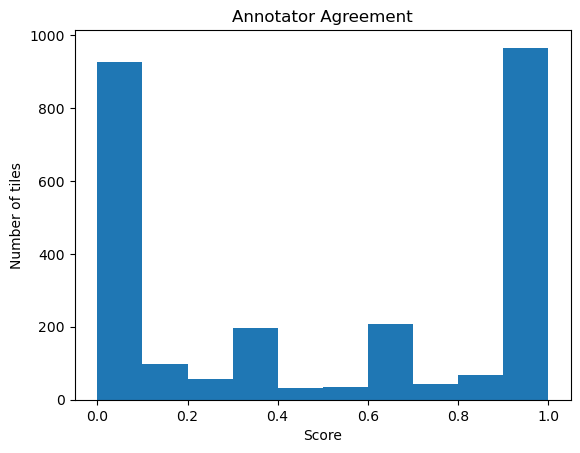

In [7]:
df1 = pd.read_csv("./annotations/train/gt_df.csv")
df2 = pd.read_csv("./annotations/test/gt_df.csv")
df = pd.concat([df1, df2], ignore_index=True)

plt.hist(df["legible-agreement"], bins=10)
plt.xlabel("Score")
plt.ylabel("Number of tiles")
plt.title("Annotator Agreement")
plt.xticks(np.arange(0, 1.1, step=0.2))
plt.show()

In [14]:
df1 = pd.read_csv("./annotations/raw/deployment_06_12_2023.csv")
df2 = pd.read_csv("./annotations/raw/deployment_09_26_2023.csv")
df3 = pd.read_csv("./annotations/raw/deployment_10_21_2023.csv")

test_df = pd.read_csv("./annotations/test/gt_df.csv")
df = pd.concat([df1, df2, df3], ignore_index=True)

acc_array = []
with open("annotator_acc.csv", "w") as f:
    f.write("annotator,accuracy,num_tiles\n")
    for user_id in set(df["UserID"].values):
        user = df[df["UserID"]==user_id]
        user.reset_index(drop=True)
        
        scores = {}
        # Scores maps TILE to [cum_score, num_scores]
        for i in user.index:
            tile = user["Tile"][i]
            score = int(user["Response"][i])
            if tile in scores:
                scores[tile][0] += score
                scores[tile][1] += 1
            else:
                scores[tile] = [score, 1]
        user = pd.DataFrame(columns=["tile","score"])
        tiles_array = []
        scores_array = []
        gt_array = []
        for score in scores:
            if score in test_df["tile"].values:
                tiles_array.append(score)
                user_score = scores[score][0]/scores[score][1]
                scores_array.append(round(user_score))
                gt_array.append(round(float(test_df[test_df["tile"]==score]["legible-agreement"])))
        user["tile"] = tiles_array
        user["score"] = scores_array
        
        correct = 0
        total = len(scores_array)
        for i in range(total):
            if scores_array[i] == gt_array[i]:
                correct += 1
        if total > 0:
            acc = correct/total
            acc_array.append(acc)
        
            f.write(user_id + "," + str(acc) + "," + str(total) + "\n")

/tmp/ipykernel_169/1527193052.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  gt_array.append(round(float(test_df[test_df["tile"]==score]["legible-agreement"])))
/tmp/ipykernel_169/1527193052.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  gt_array.append(round(float(test_df[test_df["tile"]==score]["legible-agreement"])))
/tmp/ipykernel_169/1527193052.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  gt_array.append(round(float(test_df[test_df["tile"]==score]["legible-agreement"])))
/tmp/ipykernel_169/1527193052.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  gt_array.append(roun

[1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0]
[0.52       0.59       0.61       0.63       0.632      0.639
 0.661      0.665      0.73529412 0.792      0.818      0.825
 0.82620321 0.92153589 0.93263158 0.9500998  0.96226415]


([<matplotlib.axis.XTick at 0x14ca49a10e50>,
 [Text(0, 0, '0'),
  Text(4, 0, '4'),
  Text(8, 0, '8'),
  Text(12, 0, '12'),
  Text(16, 0, '16')])

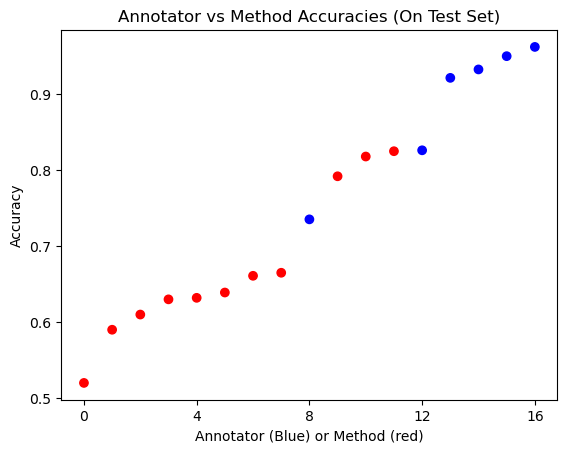

In [15]:
# Method accs are hardcoded, these are the accuracies from the paper for each method
method_accs = [0.661,0.520,0.610,0.639,0.630,0.665,0.632,0.590,0.792,0.818,0.825]
all_accs = method_accs + acc_array
labels = np.zeros(len(all_accs))
labels[:len(method_accs)] = 1
all_accs = np.asarray(all_accs)
order = np.argsort(all_accs)
for i in range(len(order)):
    order[i] = labels[order[i]]
all_accs = np.sort(all_accs)
print(order)
print(all_accs)
plt.scatter(x=np.arange(len(all_accs)), y=all_accs, c=order, cmap="bwr")
plt.xlabel("Annotator (Blue) or Method (red)")
plt.ylabel("Accuracy")
plt.title("Annotator vs Method Accuracies (On Test Set)")
plt.xticks(np.arange(0,17, step=4))